# TFLite INT8 Model Visualizer & Inspector

This notebook parses, inspects, and visualizes TensorFlow Lite (`.tflite`) model architectures, tensor shapes, data types (`int8`/`int32`), quantization parameters (scale and zero-point), and renders a visual architecture diagram.

## 1. Import Libraries & Configure Setup

In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# Path to target INT8 TFLite model
MODEL_PATH = 'cnn_int8_Future_Hypotension.tflite'
if not os.path.exists(MODEL_PATH):
    MODEL_PATH = 'CNN/models_int8/cnn_int8_Future_Hypotension.tflite'

print(f'[Visualizer] Ready to inspect: {MODEL_PATH}')

I0000 00:00:1787669663.336847  123043 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787669663.339290  123043 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1787669663.395428  123043 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1787669664.972228  123043 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

[Visualizer] Ready to inspect: cnn_int8_Future_Hypotension.tflite


## 2. Input & Output Tensor Inspection

In [2]:
interpreter = tf.lite.Interpreter(model_path=MODEL_PATH)
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print('=' * 75)
print('INPUT TENSORS:')
for inp in input_details:
    print(f"  • Name        : {inp['name']}")
    print(f"  • Shape       : {inp['shape']}")
    print(f"  • Data Type   : {inp['dtype']}")
    print(f"  • Scale       : {inp['quantization_parameters']['scales']}")
    print(f"  • Zero Point  : {inp['quantization_parameters']['zero_points']}")

print('\n' + '=' * 75)
print('OUTPUT TENSORS:')
for out in output_details:
    print(f"  • Name        : {out['name']}")
    print(f"  • Shape       : {out['shape']}")
    print(f"  • Data Type   : {out['dtype']}")
    print(f"  • Scale       : {out['quantization_parameters']['scales']}")
    print(f"  • Zero Point  : {out['quantization_parameters']['zero_points']}")
print('=' * 75)

INPUT TENSORS:
  • Name        : serving_default_keras_tensor:0
  • Shape       : [  1 600  19]
  • Data Type   : <class 'numpy.int8'>
  • Scale       : [1.7769935]
  • Zero Point  : [-37]

OUTPUT TENSORS:
  • Name        : StatefulPartitionedCall_1:0
  • Shape       : [1 1]
  • Data Type   : <class 'numpy.int8'>
  • Scale       : [0.00390625]
  • Zero Point  : [-128]


/home/logan78/.local/lib/python3.10/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


## 3. Complete Internal Tensor Map Table

In [3]:
tensor_details = interpreter.get_tensor_details()
print(f"{'ID':<4} | {'Tensor Name':<55} | {'Shape':<15} | {'Dtype':<15}")
print('-' * 95)

for detail in tensor_details:
    tid = detail['index']
    name = detail['name']
    shape = str(detail['shape'])
    dtype = str(detail['dtype']).replace("<class 'numpy.", "").replace("'>", "")
    print(f"{tid:<4} | {name:<55} | {shape:<15} | {dtype:<15}")

ID   | Tensor Name                                             | Shape           | Dtype          
-----------------------------------------------------------------------------------------------
0    | serving_default_keras_tensor:0                          | [  1 600  19]   | int8           
1    | arith.constant                                          | []              | int32          
2    | functional_1/conv1d_1/convolution/Squeeze               | [3]             | int32          
3    | arith.constant1                                         | []              | int32          
4    | functional_1/max_pooling1d_1/MaxPool1d/Squeeze          | [3]             | int32          
5    | functional_1/conv1d_1_2/convolution/Squeeze             | [3]             | int32          
6    | functional_1/max_pooling1d_1_2/MaxPool1d/Squeeze        | [3]             | int32          
7    | functional_1/conv1d_2_1/convolution/Squeeze             | [3]             | int32          
8    | functi

## 4. Visual Architecture Flowchart Diagram

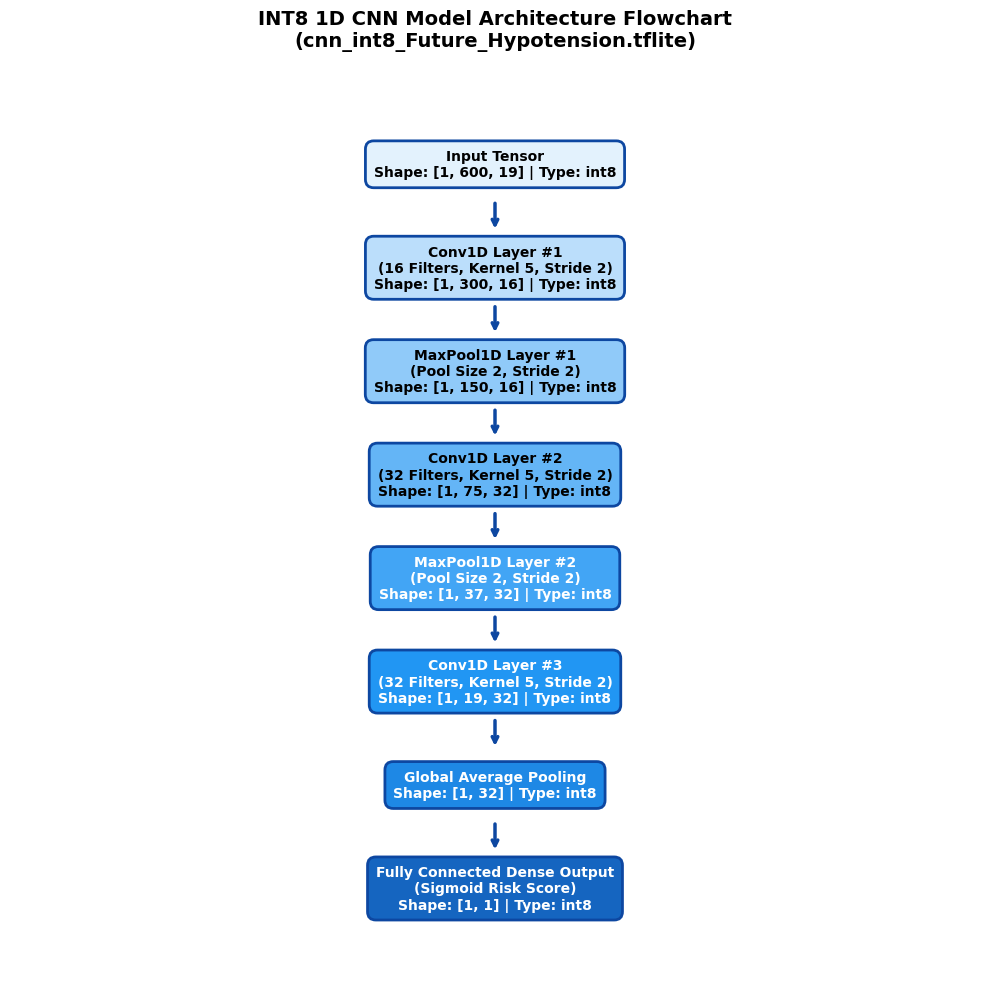

[Visualizer] Saved diagram to: cnn_int8_Hypotension_architecture.png


In [4]:
fig, ax = plt.subplots(figsize=(10, 10))
ax.axis('off')
ax.set_title('INT8 1D CNN Model Architecture Flowchart\n(cnn_int8_Future_Hypotension.tflite)', fontsize=14, fontweight='bold', pad=20)

layer_names = [
    ('Input Tensor', '[1, 600, 19]', 'int8', '#e3f2fd'),
    ('Conv1D Layer #1\n(16 Filters, Kernel 5, Stride 2)', '[1, 300, 16]', 'int8', '#bbdefb'),
    ('MaxPool1D Layer #1\n(Pool Size 2, Stride 2)', '[1, 150, 16]', 'int8', '#90caf9'),
    ('Conv1D Layer #2\n(32 Filters, Kernel 5, Stride 2)', '[1, 75, 32]', 'int8', '#64b5f6'),
    ('MaxPool1D Layer #2\n(Pool Size 2, Stride 2)', '[1, 37, 32]', 'int8', '#42a5f5'),
    ('Conv1D Layer #3\n(32 Filters, Kernel 5, Stride 2)', '[1, 19, 32]', 'int8', '#2196f3'),
    ('Global Average Pooling', '[1, 32]', 'int8', '#1e88e5'),
    ('Fully Connected Dense Output\n(Sigmoid Risk Score)', '[1, 1]', 'int8', '#1565c0')
]

y_pos = np.linspace(0.9, 0.1, len(layer_names))
x_pos = 0.5

for i, (title, shape, dtype, color) in enumerate(layer_names):
    box_text = f"{title}\nShape: {shape} | Type: {dtype}"
    ax.text(x_pos, y_pos[i], box_text, ha='center', va='center', fontsize=10, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.6', facecolor=color, edgecolor='#0d47a1', lw=2),
            color='white' if i >= 4 else 'black')
    
    if i < len(layer_names) - 1:
        ax.annotate('', xy=(x_pos, y_pos[i+1] + 0.04), xytext=(x_pos, y_pos[i] - 0.04),
                    arrowprops=dict(arrowstyle='->', lw=2.5, color='#0d47a1'))

plt.tight_layout()
output_plot = 'cnn_int8_Hypotension_architecture.png'
plt.savefig(output_plot, dpi=300, bbox_inches='tight')
plt.show()
print(f'[Visualizer] Saved diagram to: {output_plot}')